TSP & SPP COUPLED CODE


In [57]:
import numpy as np
import rasterio as rio
from rasterio.plot import show
import matplotlib.pyplot as plt
from time import perf_counter
import pandas as pd
import elevation 
import random
import copy
import datetime
import BORAS_v1
import itertools
import math
import cbor2


In [58]:
class path_info:
        def __init__(self,name,eu_fit,r_fit,bpath,t_trav,s_time):
            self.name = name
            self.eu_fit = eu_fit
            self.r_fit = r_fit
            self.bpath = bpath
            self.t_trav = t_trav
            self.s_time = s_time
            
def crossover3(parent1,parent2,crossover_rate=0.9):
    if random.random()< crossover_rate:
            crossover_point= random.randint(0,(len(parent1)-1))
            child = parent1[:crossover_point]+(parent2[crossover_point:])
            return child
    else:
        return parent1
    
def mutation2(path, mutation_rate=0.1):
    if random.random()< mutation_rate:
            mutation_point1= random.randint(0,(len(path)))
            mutation_point2= random.randint(0,(len(path)))
            place_holder = path[mutation_point1]
            path[mutation_point1] = path[mutation_point2]
            path[mutation_point2] = place_holder
    return path

def canonical_form(array):
    n = len(array)
    
    # Create all rotations of the array
    rotations = [array[i:] + array[:i] for i in range(n)]
    
    # Create all rotations of the reversed array
    reversed_array = array[::-1]
    reverse_rotations = [reversed_array[i:] + reversed_array[:i] for i in range(n)]
    
    # Combine and find the lexicographically smallest rotation
    all_rotations = rotations + reverse_rotations
    smallest_rotation = min(all_rotations)
    
    return smallest_rotation

def uniform_based_order(individual_1, individual_2, shuffle_size=5):
    """
    uniform based order crossover
    
    :param individual_1: 
    :param individual_2: 
    :param shuffle_size: 
    :return: two children
    """

    child_1 = copy.deepcopy(individual_1)
    child_2 = copy.deepcopy(individual_2)

    size = min(len(child_1), len(child_2))
    if size < shuffle_size:
        shuffle_size = size - 1

    index = [*range(size)]
    bit_mask = set(random.sample(index, shuffle_size))

    shuffle_1 = [individual_1[idx] for idx in bit_mask]
    shuffle_2 = [individual_2[idx] for idx in bit_mask]

    inv_bit_mask = set(index) - bit_mask

    parent1 = [individual_1[i] for i in inv_bit_mask]
    parent2 = [individual_2[i] for i in inv_bit_mask]

    order_shuffle_1 = set(shuffle_1)
    order_shuffle_2 = set(shuffle_2)

    can_shuffle = order_shuffle_1 & order_shuffle_2
    remain_shuffle = order_shuffle_1 ^ order_shuffle_2

    # create order from data
    order_shuffle_1 = [x for x in shuffle_1 if x in can_shuffle]
    order_shuffle_2 = [x for x in shuffle_2 if x in can_shuffle]

    parent1 = [x for x in parent1 if x in remain_shuffle]
    parent2 = [x for x in parent2 if x in remain_shuffle]

    order_shuffle_1 += parent1
    order_shuffle_2 += parent2

    i = 0
    for idx in bit_mask:
        child_1[idx] = order_shuffle_2[i]
        child_2[idx] = order_shuffle_1[i]
        i += 1

    return child_1, child_2

In [59]:
#PROBLEM DEFINITION
mean_speed =0.0175
start_epoch = '2028-02-13 00:00:00.001' # For GA
start_time_range = BORAS_v1.generate_time_range(11000.499, 11001.0, 0.1) #For TDD
time_dependent = True
mode = 'Single' #'Single'or 'Tour'
tsp_mode = 'OL' #Can be Closed Loop "CL" or Open Loop "OL"
algorithm ="TDD" #"GA" or "Dijkistra" or "TDD"
pop_size = 128 #TSP Population size
max_generations = 100 #TSP Maximum generations
#filename = "data/dems/plateau_2m_slope_1m_fixed.tif" #SLOPE MAP
filename = 'data/dems/test_case_A.tif'
#filename = 'data/dems/lunargem_4to5_2m_slope_1m.tif'
illumination_filename = 'data/illumination/test_case_A.cbor' #If TDD or GA
dem = rio.open(filename)
with open(illumination_filename, "rb") as file: #ILLUMINATION DICT
    roots = cbor2.load(file)
#waypoints = list([(53,53),(80,345),(234,253),(347,56),(125,190)])
#waypoints = list([(2973, 784),(2793, 948),(2655, 1078),(2666, 1366),(2474, 1560),(2672, 1706),(2529, 2115),(2575, 2412),(2672, 2558),(2996, 2637),(3117, 3049)]) #LUNARGEM RS1 Waypoint list
#waypoints = list([(2973, 784),(2793, 948),(2655, 1078),(2666, 1366),(2474, 1560),(2672, 1706),(2529, 2115),(2575, 2412),(2672, 2558),(2996, 2637),(3117, 3049),(2741, 1454)]) #LUNARGEM RS1 w/ WP3a Waypoint list
#waypoints = list([(2973, 784),(2793, 948),(2655, 1078),(2666, 1366),(2474, 1560),(2672, 1706),(2529, 2115),(2575, 2412),(2672, 2558),(2996, 2637),(3117, 3049),(2727,1797),(2649,2145)]) #LUNARGEM RS1 w/ WP5b&c Waypoint list
#waypoints= list([(2973, 784),(2793, 948),(2655, 1078),(2666, 1366),(2474, 1560),(2672, 1706),(2529, 2115),(2575, 2412),(2672, 2558),(2996, 2637),(3117, 3049),(2741, 1454),(2727,1797),(2649,2145)]) #LUNARGEM RS1 w/ WP5b&c and WP3a Waypoint list
#waypoints = list([(50,350),(150,350),(140,266),(233,233),(168,168),(203,100),(345,75)])
#waypoints_d = [(5.340422, 18.696975),(5.334098, 18.691614), (5.329296,18.687256), (5.329713,18.677819),(5.322971,18.671367),(5.329852,18.666616),(5.324935,18.653105),(5.326486,18.643316),(5.329854,18.638515),(5.34129,18.63575),(5.345378,18.622315)]#,(5.332286,18.674938),(5.331758,18.663559),(5.329136,18.65205)]
#waypoints = BORAS_v1.coord_to_px(waypoints_d,dem)
waypoints = list([(8,1),(1,8)])
print(waypoints)

[(8, 1), (1, 8)]


In [60]:
#PRE-COMPUTE FITNESSS FOR ALL PERMUTATIONS
order = list(np.arange((len(waypoints))))    
permutations = list(itertools.permutations(order,r=2))
info_paths = []
total_t_time = 0
max_min = False
for i in range(len(permutations)):
    start = waypoints[permutations[i][0]]
    end = waypoints[permutations[i][1]]
    distance=np.sqrt((start[0]-end[0])**2 + (start[1]-end[1])**2)
    t_time = distance/mean_speed
    info_paths.append(path_info(permutations[i],t_time,0,[],0))

In [61]:
#TSP GA CODE
def tsp(waypoints,pop_size,max_generations,tsp_mode):
    generations = 0 #Initialize Generations
    pop = [] 
    fitness = []
    same = 0
    best_fitness = 0
    #GENERATE INITIAL POPULATION
    for indv in range(pop_size):
        random.shuffle(order)
        populant = copy.deepcopy(order)
        populant = canonical_form(populant)
        pop.append(populant)
        total_fit = 0
        for i in range(len(waypoints)):
            idx_perm = permutations.index((order[(i-1)],order[i]))
            if info_paths[idx_perm].r_fit == 0:
                fit = info_paths[idx_perm].eu_fit
            else:
                fit = info_paths[idx_perm].r_fit
            total_fit = total_fit + fit
        total_fit = 1-(1/total_fit)
        fitness.append(total_fit)

    while not BORAS_v1.termination_condition(generations,max_generations)  or same>= 33:
        generations += 1
        next_gen = []
        old_best_fitness = best_fitness
        #SELECT POPULATION FOR NEXT GEN
        selected_pop_size = int(pop_size/8)
        select_fitness = copy.deepcopy(fitness)
        print(select_fitness)
        pop_w_elite = copy.deepcopy(pop)
        elite_pop = BORAS_v1.select_pop_max2(pop,select_fitness, pop_size,max_min, num_to_select=selected_pop_size)
        select_fitness = copy.deepcopy(fitness)
        selected_pop = BORAS_v1.select_pop_rand(pop_w_elite,select_fitness, pop_size, selected_pop_size*6)
        selected_pop = selected_pop +  elite_pop
        
        pop_indexes = list(np.arange(0,pop_size,1,dtype=int))

        #ELITE
        for i in range(selected_pop_size):
            next_gen.append(elite_pop[i])

        #CROSSOVER & MUTATION
        pop_indexes = list(np.arange(0,( selected_pop_size*6),1,dtype=int))
        random.shuffle(selected_pop)
        for _ in range(0, ( selected_pop_size*6),2):
                    i,j = random.sample(pop_indexes,k=2)
                    pop_indexes.remove(i)
                    pop_indexes.remove(j)
                    parent1 =[]
                    parent2=[]
                    child1=[]
                    child2=[]
                    parent1 , parent2 = selected_pop[i],selected_pop[j]
                    child1,child2 = uniform_based_order(parent1,parent2)#crossover3(parent1,parent2), crossover3(parent2,parent1)
                    #MUTATION
                    child1,child2 = BORAS_v1.mutation2(child1),BORAS_v1.mutation2(child2)
                    child1 = canonical_form(child1)
                    child2 = canonical_form(child2)
                    next_gen.append(child1)
                    next_gen.append(child2)


        for indv in range(selected_pop_size):
            random.shuffle(order)
            populant = copy.deepcopy(order)
            populant = canonical_form(populant)
            next_gen.append(populant)

        pop[:] = next_gen
        fitness = []
        print(pop)
        #EVALUATE POPULATION
        for path in pop:
            total_fit = 0
            if tsp_mode == 'CL':
                for i in range(len(path)):
                    idx_perm = permutations.index((path[(i-1)],path[i]))
                    if info_paths[idx_perm].r_fit == 0:
                        fit = info_paths[idx_perm].eu_fit
                    else:
                        fit = info_paths[idx_perm].r_fit
                    total_fit = total_fit + fit
            elif tsp_mode == 'OL':
                for i in range(len(path)-1):
                    idx_perm = permutations.index((path[i],path[(i+1)]))
                    if info_paths[idx_perm].r_fit == 0:
                        fit = info_paths[idx_perm].eu_fit
                    else:
                        fit = info_paths[idx_perm].r_fit
                    total_fit = total_fit + fit
            total_fit = float(1-(1/total_fit))
            fitness.append(total_fit)       
        best_fitness = min(fitness)
        best_path_idx = fitness.index(best_fitness)
        print(f'Generation {generations}: Best fitness = {best_fitness}.')
        best_path = pop[best_path_idx]
    if best_fitness == old_best_fitness:
        same += 1
    else:
        same = 0
    return best_path, best_fitness


In [62]:
if mode == 'Tour':
    best_path, best_fitness = tsp(waypoints,pop_size,max_generations,tsp_mode)
    print('Best path found:',best_path)
    old_best_fitness = 10
    old_best_path =[]
    gen_eq = 0
    #best_path = [0,1,2,3,4]
    while (old_best_fitness != best_fitness) or (best_path!=old_best_path):
        old_best_fitness = best_fitness
        old_best_path = best_path
        if time_dependent == True:
            if tsp_mode == 'CL':
                for i in range(len(best_path)):
                    idx_perm = permutations.index((best_path[(i-1)],best_path[i]))
                    idx_perm_r = permutations.index((best_path[i],best_path[(i-1)]))
                    if info_paths[idx_perm].r_fit == 0:
                        dem_c = []
                        start = waypoints[best_path[(i-1)]]
                        end = waypoints[best_path[i]]
                        new_filename = "crop-file"
                        BORAS_v1.crop_grid(start,end,filename,new_filename)
                        dem_c = rio.open(new_filename)
                        dem_array = dem_c.read(1).astype('float64')
                        fig2, ax = plt.subplots(1, figsize=(5, 5))
                        plt.imshow(dem_array, cmap='Greys_r',interpolation='none')
                        plt.colorbar()
                        plt.axis("on")
                        plt.show()
                        new_start, new_end = BORAS_v1.new_start_end(start,end,dem_c)
                        if algorithm == "GA":
                            bfit_ga_path,fitnesses_gen,traverse_time,best_ga_path = BORAS_v1.ga(new_start,new_end,dem_c,start_epoch, roots)
                        elif algorithm == "TDD":
                            start_time,traverse_time,best_ga_path = BORAS_v1.TDD(new_start,new_end,dem_array)
                        info_paths[idx_perm].r_fit = traverse_time
                        info_paths[idx_perm_r].r_fit = traverse_time
                        best_ga_path_trans = BORAS_v1.translate_back_to_original(start, end, best_ga_path)
                        info_paths[idx_perm].bpath = best_ga_path_trans
                        info_paths[idx_perm_r].bpath = best_ga_path_trans
                        info_paths[idx_perm].t_trav = traverse_time
                        info_paths[idx_perm_r].t_trav = traverse_time
                        dem_c.close()
            elif tsp_mode == 'OL':
                for i in range(len(best_path)-1):
                    idx_perm = permutations.index((best_path[i],best_path[(i+1)]))
                    idx_perm_r = permutations.index((best_path[(i+1)],best_path[i]))
                    if info_paths[idx_perm].r_fit == 0:
                        dem_c = []
                        start = waypoints[best_path[i]]
                        end = waypoints[best_path[(i+1)]]
                        new_filename = "crop-file"
                        BORAS_v1.crop_grid(start,end,filename,new_filename)
                        dem_c = rio.open(new_filename)
                        dem_array = dem_c.read(1).astype('float64')
                        fig2, ax = plt.subplots(1, figsize=(5, 5))
                        plt.imshow(dem_array, cmap='Greys_r',interpolation='none')
                        plt.colorbar()
                        plt.axis("on")
                        plt.show()
                        new_start, new_end = BORAS_v1.new_start_end(start,end,dem_c)
                        if algorithm == "GA":
                            bfit_ga_path,fitnesses_gen,traverse_time,best_ga_path = BORAS_v1.ga(new_start,new_end,dem_c,start_epoch,roots)
                        elif algorithm == "TDD":
                            traverse_time,best_ga_path = BORAS_v1.TDD(new_start,new_end,dem_array)
                        info_paths[idx_perm].r_fit = traverse_time
                        info_paths[idx_perm_r].r_fit = traverse_time
                        best_ga_path_trans = BORAS_v1.translate_back_to_original(start, end, best_ga_path)
                        info_paths[idx_perm].bpath = best_ga_path_trans
                        info_paths[idx_perm_r].bpath = best_ga_path_trans
                        info_paths[idx_perm].t_trav = traverse_time
                        info_paths[idx_perm_r].t_trav = traverse_time
                        dem_c.close()
            best_path, best_fitness = tsp(waypoints,pop_size,max_generations,tsp_mode)
        else:
            if tsp_mode == 'CL':
                for i in range(len(best_path)):
                    idx_perm = permutations.index((best_path[(i-1)],best_path[i]))
                    idx_perm_r = permutations.index((best_path[i],best_path[(i-1)]))
                    if info_paths[idx_perm].r_fit == 0:
                        dem_c = []
                        start = waypoints[best_path[(i-1)]]
                        end = waypoints[best_path[i]]
                        new_filename = "crop-file"
                        BORAS_v1.crop_grid(start,end,filename,new_filename)
                        dem_c = rio.open(new_filename)
                        dem_array = dem_c.read(1).astype('float64')
                        fig2, ax = plt.subplots(1, figsize=(5, 5))
                        plt.imshow(dem_array, cmap='Greys_r',interpolation='none')
                        plt.colorbar()
                        plt.axis("on")
                        plt.show()
                        new_start, new_end = BORAS_v1.new_start_end(start,end,dem_c)
                        if algorithm == "GA":
                            bfit_ga_path,fitnesses_gen,traverse_time,best_ga_path = BORAS_v1.ga(new_start,new_end,dem_c,start_epoch, roots)
                        elif algorithm == "Dijkistra":
                            traverse_time,best_ga_path = BORAS_v1.djikistras(new_start,new_end,dem_array)
                        info_paths[idx_perm].r_fit = traverse_time
                        info_paths[idx_perm_r].r_fit = traverse_time
                        best_ga_path_trans = BORAS_v1.translate_back_to_original(start, end, best_ga_path)
                        info_paths[idx_perm].bpath = best_ga_path_trans
                        info_paths[idx_perm_r].bpath = best_ga_path_trans
                        info_paths[idx_perm].t_trav = traverse_time
                        info_paths[idx_perm_r].t_trav = traverse_time
                        dem_c.close()
            elif tsp_mode == 'OL':
                for i in range(len(best_path)-1):
                    idx_perm = permutations.index((best_path[i],best_path[(i+1)]))
                    idx_perm_r = permutations.index((best_path[(i+1)],best_path[i]))
                    if info_paths[idx_perm].r_fit == 0:
                        dem_c = []
                        start = waypoints[best_path[i]]
                        end = waypoints[best_path[(i+1)]]
                        new_filename = "crop-file"
                        BORAS_v1.crop_grid(start,end,filename,new_filename)
                        dem_c = rio.open(new_filename)
                        dem_array = dem_c.read(1).astype('float64')
                        fig2, ax = plt.subplots(1, figsize=(5, 5))
                        plt.imshow(dem_array, cmap='Greys_r',interpolation='none')
                        plt.colorbar()
                        plt.axis("on")
                        plt.show()
                        new_start, new_end = BORAS_v1.new_start_end(start,end,dem_c)
                        if algorithm == "GA":
                            bfit_ga_path,fitnesses_gen,traverse_time,best_ga_path = BORAS_v1.ga(new_start,new_end,dem_c,start_epoch,roots)
                        elif algorithm == "Dijkistra":
                            traverse_time,best_ga_path = BORAS_v1.djikistras(new_start,new_end,dem_array)
                        info_paths[idx_perm].r_fit = traverse_time
                        info_paths[idx_perm_r].r_fit = traverse_time
                        best_ga_path_trans = BORAS_v1.translate_back_to_original(start, end, best_ga_path)
                        info_paths[idx_perm].bpath = best_ga_path_trans
                        info_paths[idx_perm_r].bpath = best_ga_path_trans
                        info_paths[idx_perm].t_trav = traverse_time
                        info_paths[idx_perm_r].t_trav = traverse_time
                        dem_c.close()
            best_path, best_fitness = tsp(waypoints,pop_size,max_generations,tsp_mode)
        print('Best path found:',best_path)
else:
    if algorithm == "GA":
        bfit_ga_path,fitnesses_gen,traverse_time,best_ga_path = BORAS_v1.ga(waypoints[0],waypoints[1],dem,start_epoch,roots)
    elif algorithm == "Dijkistra":
        dem_array = dem.read(1).astype('float64')
        traverse_time,best_ga_path = BORAS_v1.djikistras(waypoints[0],waypoints[1],dem_array)
        print('Best path found:',best_ga_path)
    elif algorithm == "TDD":
        slope_dem = dem.read(1).astype('float64')
        opt_start_time, best_ga_path, traverse_time = BORAS_v1.TDD(waypoints[0],waypoints[1],slope_dem,roots,start_time_range)
        

Optimal Departure Time: 11000.499, Path Taken: [(8, 1), (7, 2), (6, 3), (6, 4), (5, 5), (4, 6), (3, 7), (3, 8), (2, 9), (1, 8)], Total Traverse Time: 0:09:22
Time elapsed: 1.6836633682250977


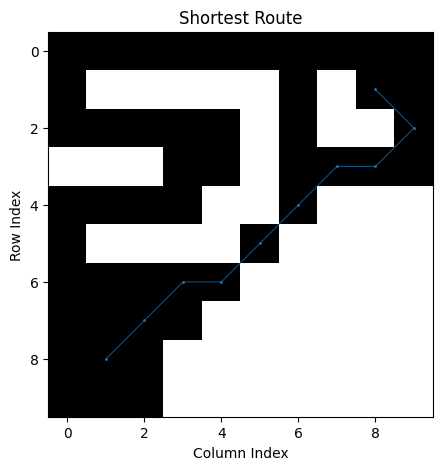

In [63]:
%matplotlib inline
import mpld3
import matplotlib.cm as cm
mpld3.disable_notebook()
best_path = [0, 4,3,2,1]
dem = rio.open(filename)
slope_dem =dem.read(1)
if mode == 'Tour':
    color = iter(cm.rainbow(np.linspace(0, 1, len(best_path))))
    fig, ax = plt.subplots(1, figsize=(5, 5))
    ax.imshow(slope_dem, origin='upper', cmap='Greys_r', interpolation='none')
    total_trav_time = 0
    for i in range(len(best_path)-1):
        trav_time = 0
        #idx_perm = permutations.index((best_path[i-1],best_path[i]))
        idx_perm = permutations.index((best_path[i],best_path[i+1]))
        best_ga_path = info_paths[idx_perm].bpath
        trav_time = info_paths[idx_perm].t_trav
        if info_paths[idx_perm].t_trav == 0:
            trav_time = info_paths[idx_perm].eu_fit
        total_trav_time =  total_trav_time + trav_time
                # Extract x, y coordinates for path plotting
        path_x = [point[1] for point in best_ga_path]  # Col indices
        path_y = [point[0] for point in best_ga_path]  # Row indices
            # Plot path
        c = next(color)
        plt.plot(path_x, path_y, marker='o', color=c, markersize=1, linewidth=0.5)
        plt.title('Shortest Route Through the Waypoints')
else:
    fig, ax = plt.subplots(1, figsize=(5, 5))
    ax.imshow(slope_dem, origin='upper', cmap='Greys_r', interpolation='none')
    # Extract x, y coordinates for path plotting
    path_x = [point[1] for point in best_ga_path]  # Col indices
    path_y = [point[0] for point in best_ga_path]  # Row indices
    # Plot path
    plt.plot(path_x, path_y, marker='o', markersize=1, linewidth=0.5)
    plt.title('Shortest Route')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.grid(False)
plt.show()
#print(total_trav_time)

In [64]:
#t=info_pathse = str(datetime.timedelta(seconds=t))
#print(traver[permutations.index((2,7))].t_trav
#traverse_timse_time)
max_slope=15
#bpath910 = info_paths[permutations.index((8,9))].bpath
#print(bpath910)
#dem_c = []
#start = bpath910[0]
#end = bpath910[-1]
#new_filename = "crop-files"
#BORAS_v1.crop_grid(start,end,filename,new_filename)
dem_c = rio.open(filename)
slope_dem = dem_c.read(1).astype('float64')

slope = 0
flag_max_slope = 0
slope_idx = []
for i in range((len(best_ga_path)-1)):
    position = best_ga_path[i]
    slope_point = slope_dem[position[0]][position[1]]
    slope = slope + slope_point
    if slope_point > max_slope:
        flag_max_slope = 1
        slope_idx.append(i)
print(flag_max_slope)
print(slope_idx)
print(slope)
#print(bpath910[327])
#print(len(bpath910))

0
[]
0.0
